In [149]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
import seaborn as sns
# matplotlib.rcParams['figure.figsize'] = (12, 8)
# or
sns.set(rc={'figure.figsize':(20, 10)})

In [2]:
df = pd.read_csv('Relix-Sales.csv', encoding='unicode_escape')
df.shape

(11251, 15)

In [3]:
# df.head()
df.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


### Time For Data Cleaning

In [4]:
# to start data cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [5]:
# to drop unrelated/blank columns
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)
# axis=1 means the entire row, inplace=True means the line of action is saved into the dataframe

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [7]:
pd.isnull(df)
# to check if there are any null values/empty cells

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,False,False,False,False,False,False,False,False,False,False,False,False,False
11247,False,False,False,False,False,False,False,False,False,False,False,False,False
11248,False,False,False,False,False,False,False,False,False,False,False,False,False
11249,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [9]:
# so there are 12 null/empty cells in the Amount column

In [10]:
df.shape

(11251, 13)

In [11]:
# drop null values
df.dropna(inplace=True)

In [12]:
df.shape
# the empty cells have been deleted by deleting the entire row that had the empty cell

(11239, 13)

In [13]:
# to butress on dropping and inplace=True
data_test = [['tobi', 11], ['benjamin',], ['Carson', 19], ['Kelvin', 22]]
df_test = pd.DataFrame(data_test, columns=['Name', 'Age'])
df_test

,Name,Age
0,tobi,11.0
1,benjamin,NaN
2,Carson,19.0
3,Kelvin,22.0


In [14]:
df_test.dropna(inplace=True)



In [15]:
df_test

,Name,Age
0,tobi,11.0
2,Carson,19.0
3,Kelvin,22.0


In [16]:
df_pro = df_test.dropna()


In [17]:
df_pro

,Name,Age
0,tobi,11.0
2,Carson,19.0
3,Kelvin,22.0


In [18]:
# checking the datatype of the Amount column
df.head(2)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0


In [19]:
# to change the datatype of the 'Amount' to int from float
df['Amount'] = df['Amount'].astype('int64')
# run df['AMount'].dtypes or df.head(2) to check
df.head(2)
df['Amount'].dtypes


dtype('int64')

In [20]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [21]:
# rename a column
# df.rename(columns= {'Marital_Status':'Mar_Status'})


In [22]:
# describe method returns a description of the data in the Df
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [23]:
# using describe() for specific columns
df[['Age', 'Orders', 'Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


### Exploratory Data Analysis

Gender

In [24]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

<Axes: xlabel='Gender', ylabel='count'>

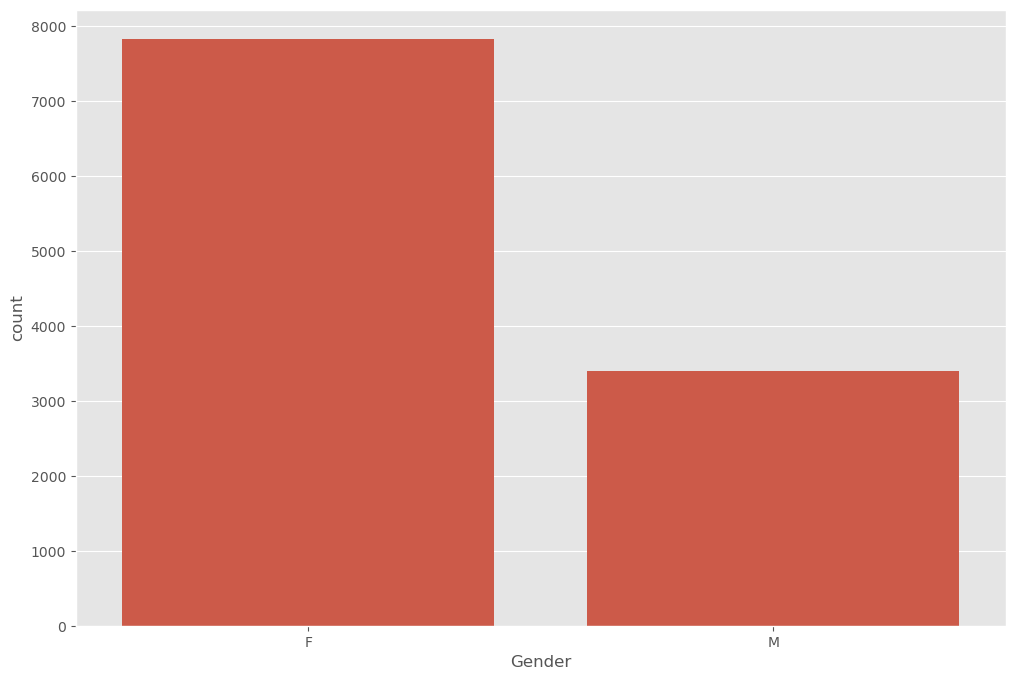

In [25]:
sns.countplot(x= 'Gender', data=df)

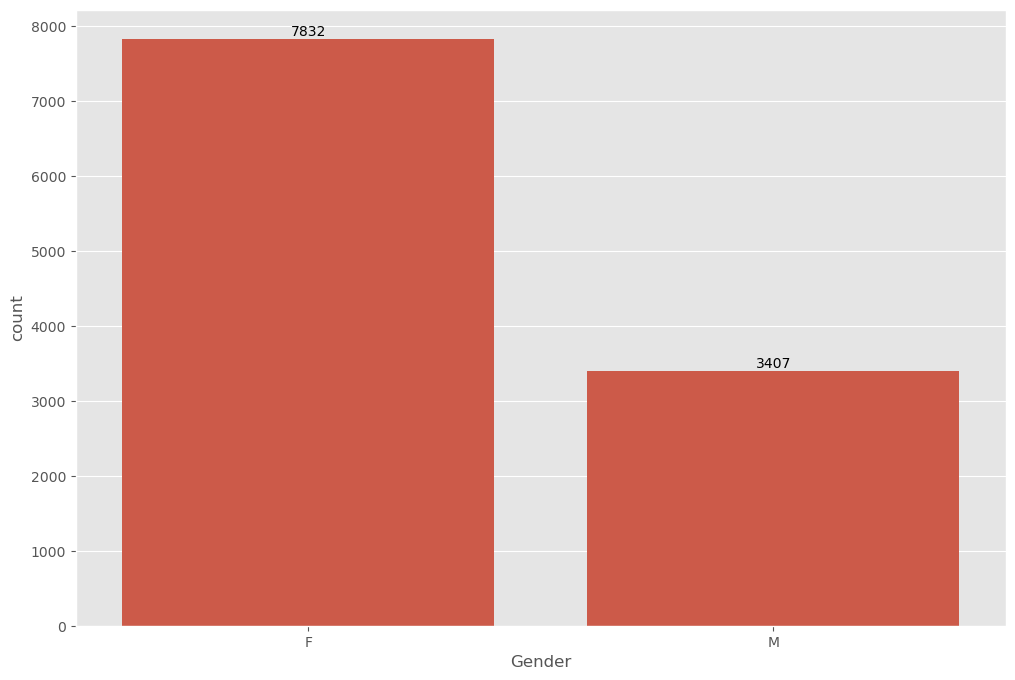

In [26]:
bx = sns.countplot(x= 'Gender', data=df)

for bars in bx.containers:
    bx.bar_label(bars)

In [27]:
# from the above plot we see the female has a higher count, they have made more purchases, they have placed more compared to males

In [28]:
# the 2nd plot
df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

,Gender,Amount
0,F,74335853
1,M,31913276


In [46]:
sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sales_gen

,Gender,Amount
0,F,74335853
1,M,31913276


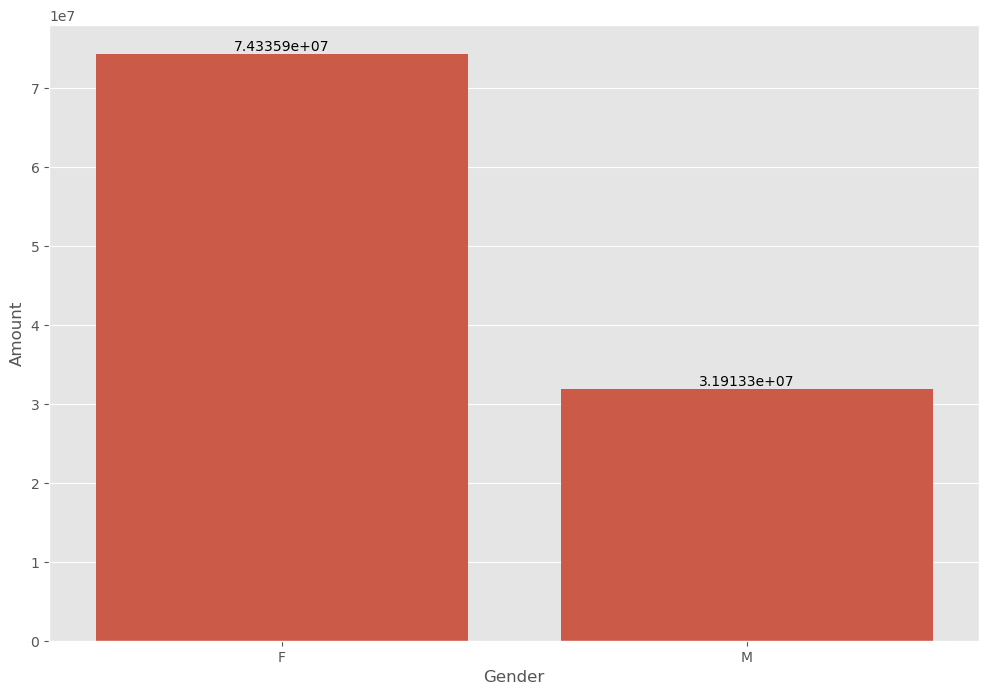

In [30]:
sales_gen_bp = sns.barplot(x='Gender',y='Amount', data=sales_gen)
for bars in sales_gen_bp.containers:
    sales_gen_bp.bar_label(bars)

##### From above plots we can see that from the 1st countplot most of the buyers are females and from the 2nd group sum plot above, the purchasing power of females are greater than men

### Age

In [32]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

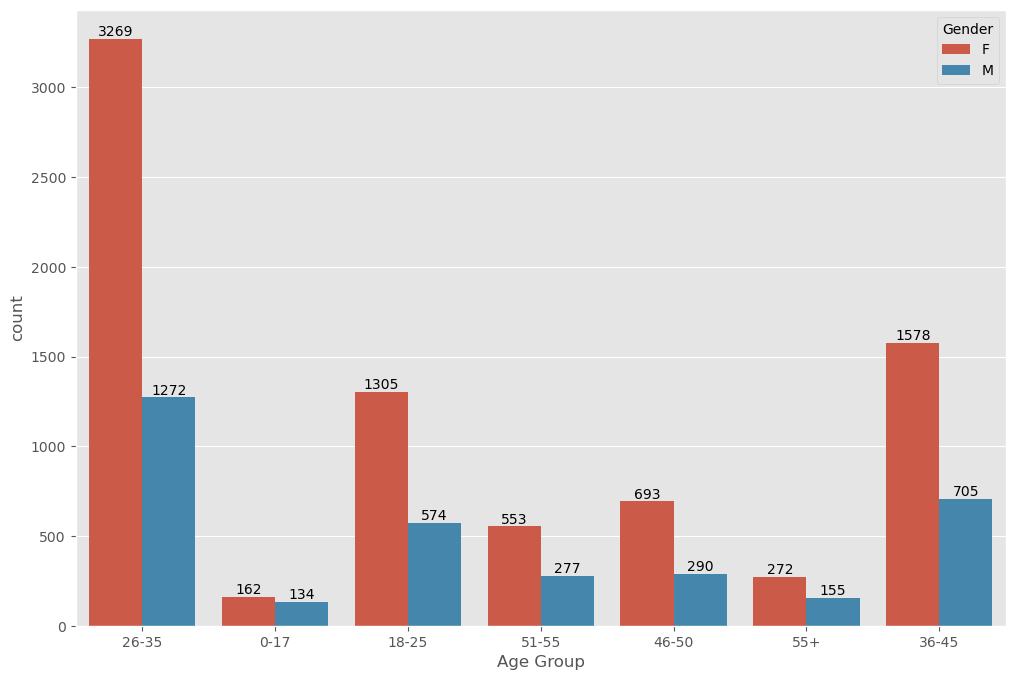

In [89]:
# Using the countplot to show the gender which the highest number of purchases in each Age group
# ax = sns.countplot(data = df, x = 'Age Group')
ax = sns.countplot(data = df, x = 'Age Group', hue='Gender')
for bars in ax.containers:
    ax.bar_label(bars)

In [77]:
# Using the groupby,sort_values and barplot to know which age group has the highest Amount of purchase.
sales_age_1 = df.groupby(['Age Group'],as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sales_age_1

,Age Group,Amount
2,26-35,42613442
3,36-45,22144994
1,18-25,17240732
4,46-50,9207844
5,51-55,8261477
6,55+,4080987
0,0-17,2699653


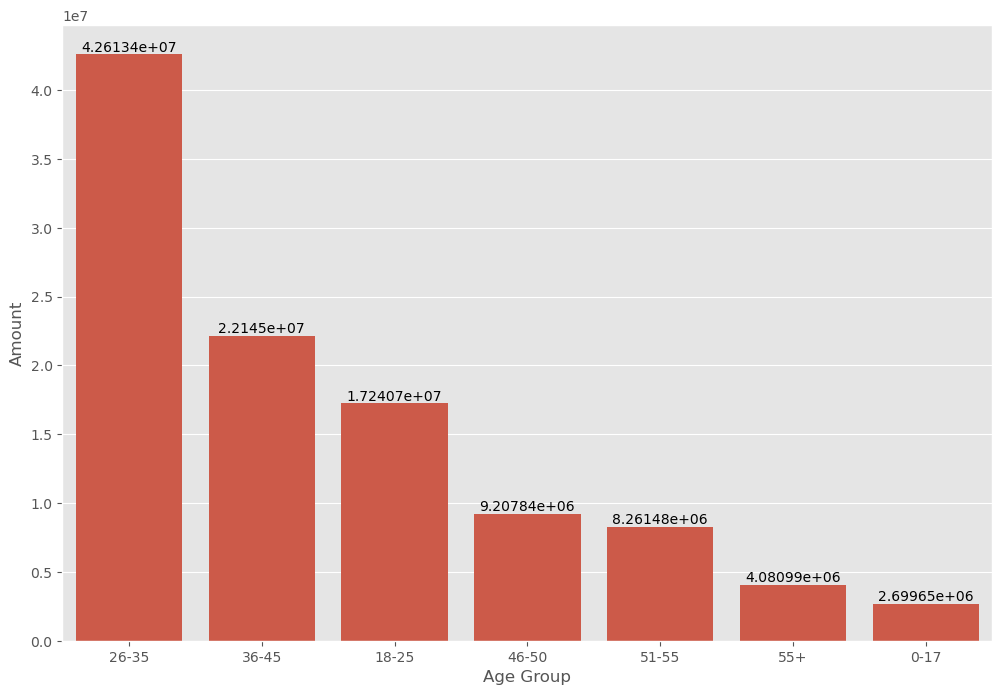

In [75]:
ax_1 = sns.barplot(data=sales_age_1, x= 'Age Group', y='Amount')
for bar in ax_1.containers:
    ax_1.bar_label(bar)

In [78]:
# Using hue as Gender and barplot to show which Gender of the age group has more Amount of purchase
sales_age = df.groupby(['Age Group', 'Gender'], as_index=False)['Amount'].sum()
sales_age
# or
# Total Amount vs Age Group
# sales_age = df.groupby(['Age Group', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=True)
# sales_age

,Age Group,Gender,Amount
0,0-17,F,1441409
1,0-17,M,1258244
2,18-25,F,11887003
3,18-25,M,5353729
4,26-35,F,30963953
5,26-35,M,11649489
6,36-45,F,15509956
7,36-45,M,6635038
8,46-50,F,6743393
9,46-50,M,2464451


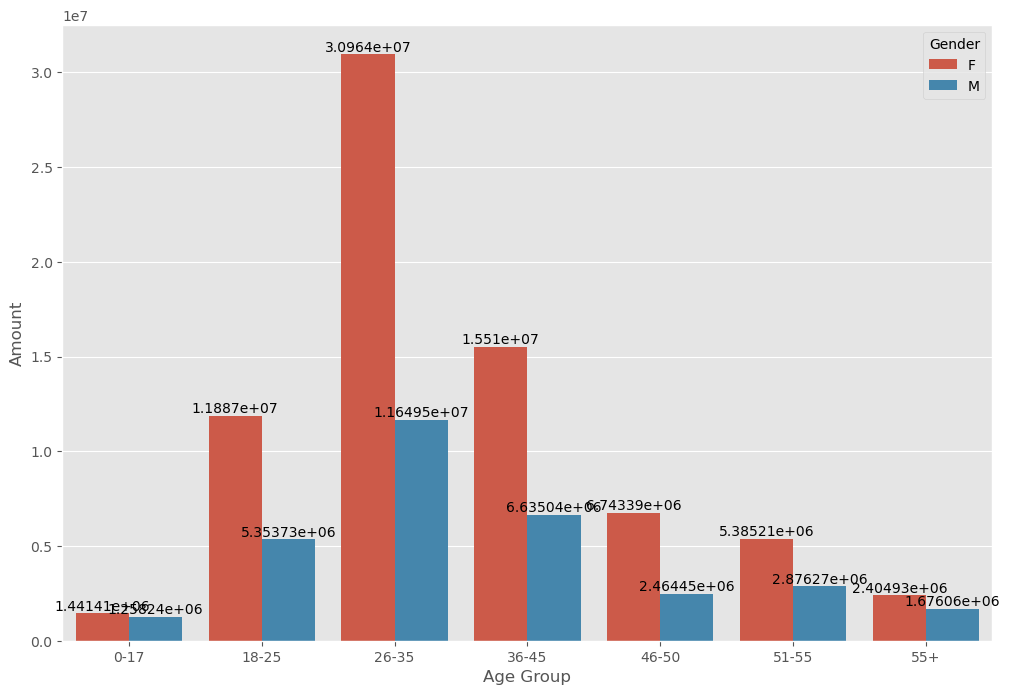

In [66]:
ax = sns.barplot(data = sales_age, x='Age Group', y='Amount', hue='Gender')
for bar in ax.containers:
    ax.bar_label(bar)

##### From above graphs we can see that most of the buyers and buyers with highest amount of purchase are of age group between 26-35yrs

### State

In [80]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [86]:
# Using the groupby,indexing, sum() and sort_values to know the state with the highest amount of purchase
sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sales_state

,State,Amount
14,Uttar Pradesh,19374968
10,Maharashtra,14427543
7,Karnataka,13523540
2,Delhi,11603818
9,Madhya Pradesh,8101142
0,Andhra Pradesh,8037146
5,Himachal Pradesh,4963368
4,Haryana,4220175
1,Bihar,4022757
3,Gujarat,3946082


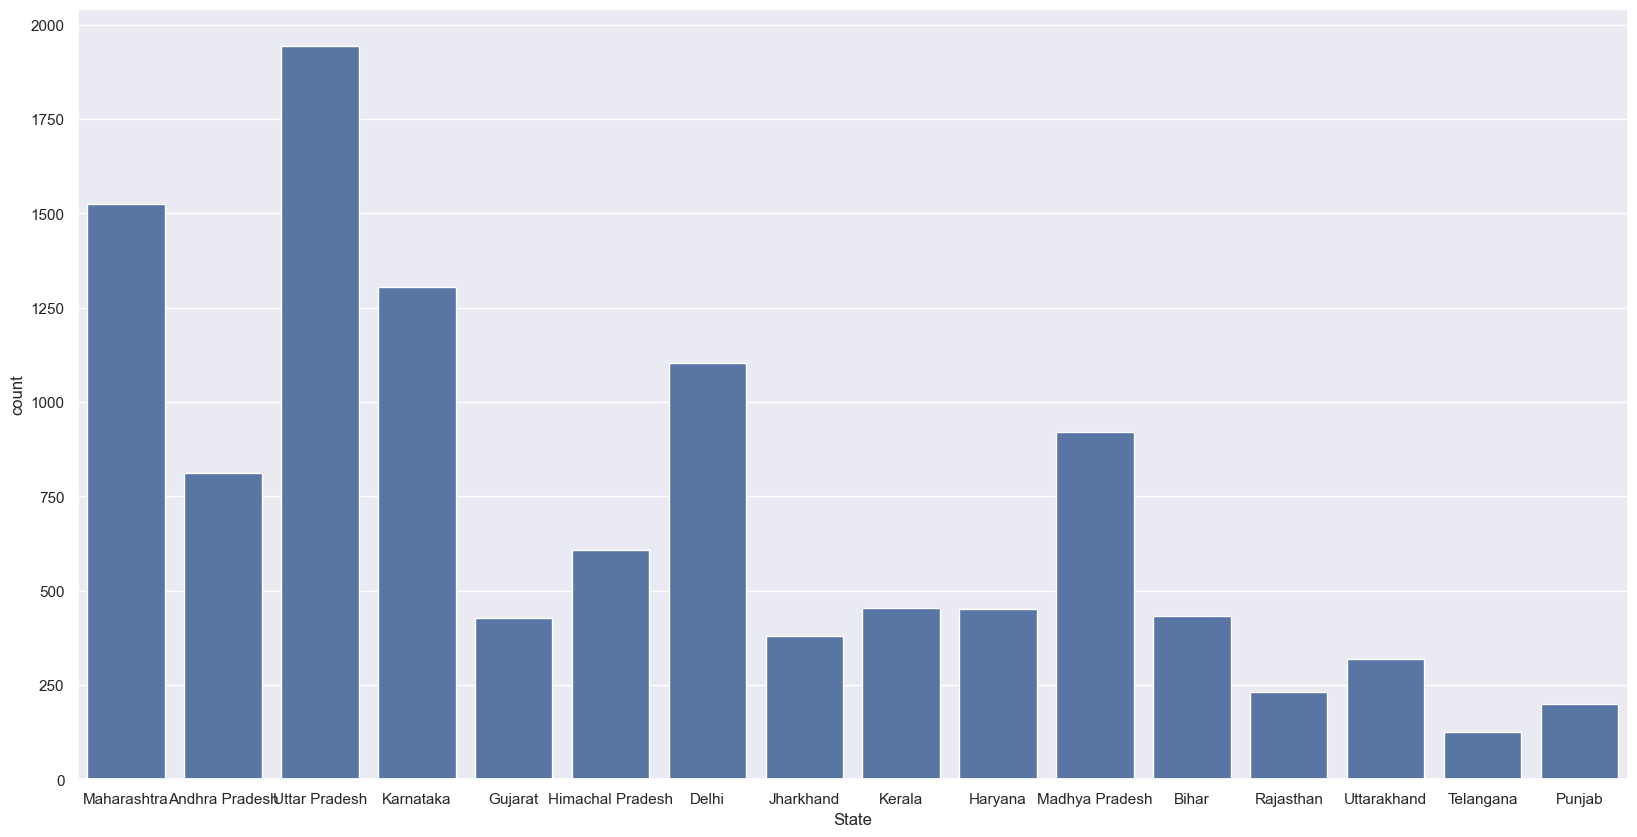

In [129]:
# use the df and sales_state data to show the countplot and barplot respectively
ax = sns.countplot(data = df, x = 'State')
# ----------or-------------
# count_of_states = df[df['State'] == 'Uttar Pradesh']
# len(count_of_states)
# ----------or-------------
# df[df['State'] == 'Uttar Pradesh'].count()

In [143]:
sales_state_3 = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)
sales_state_3


,State,Amount
14,Uttar Pradesh,19374968
10,Maharashtra,14427543
7,Karnataka,13523540
2,Delhi,11603818
9,Madhya Pradesh,8101142
0,Andhra Pradesh,8037146
5,Himachal Pradesh,4963368
4,Haryana,4220175
1,Bihar,4022757
3,Gujarat,3946082


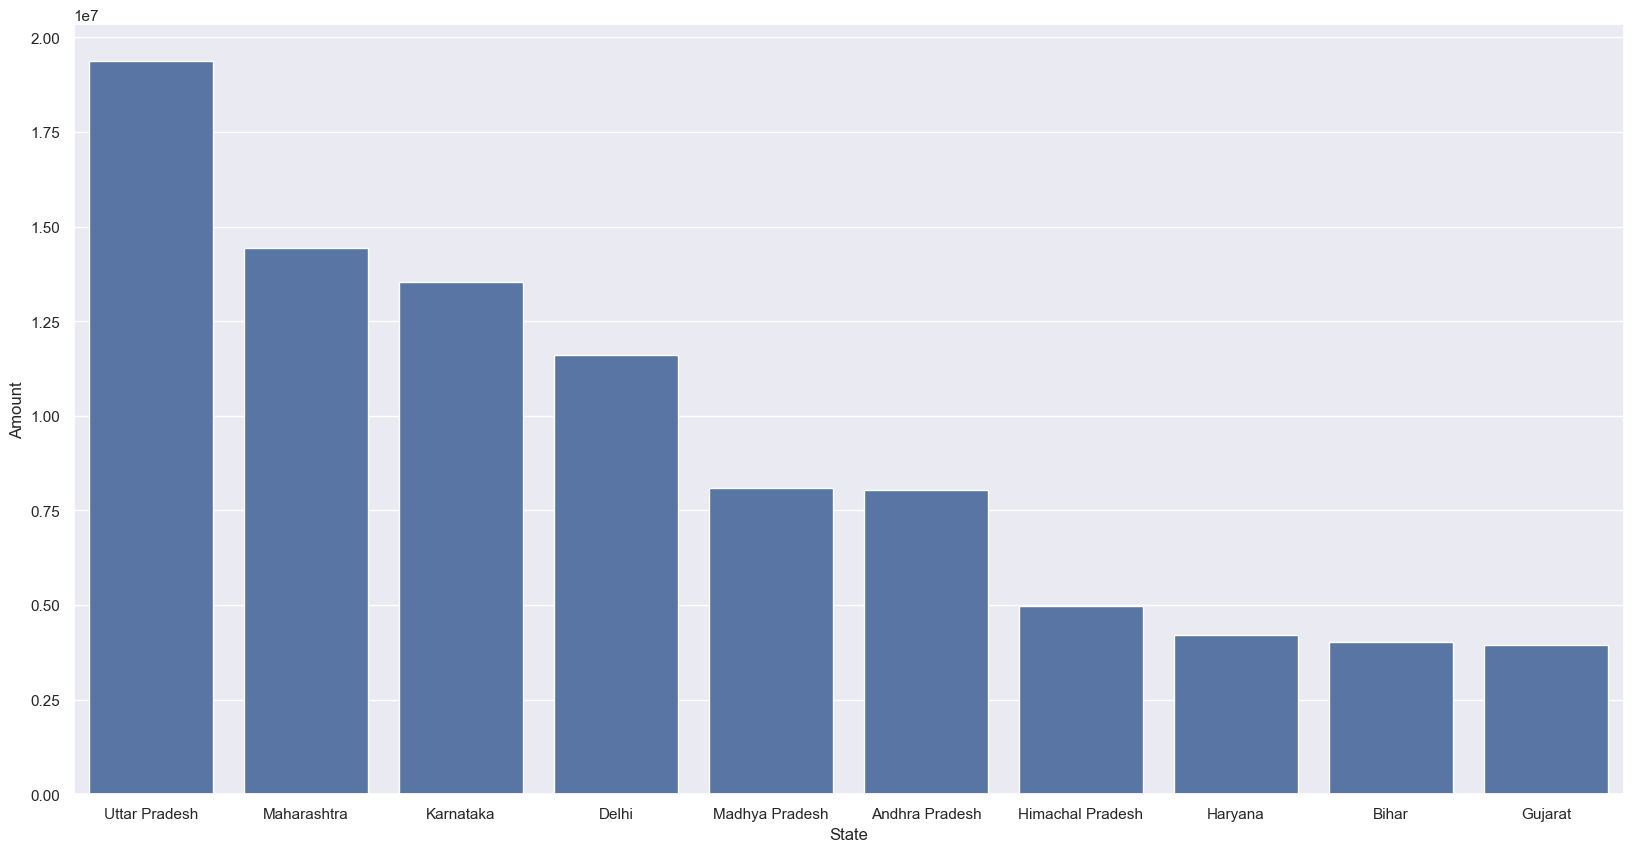

In [150]:
ax = sns.barplot(data=sales_state_3, x = 'State', y= 'Amount')

In [146]:
sales_state_2 = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
sales_state_2

,State,Orders
14,Uttar Pradesh,4807
10,Maharashtra,3810
7,Karnataka,3240
2,Delhi,2740
9,Madhya Pradesh,2252
0,Andhra Pradesh,2051
5,Himachal Pradesh,1568
8,Kerala,1137
4,Haryana,1109
3,Gujarat,1066


<Axes: xlabel='State', ylabel='Orders'>

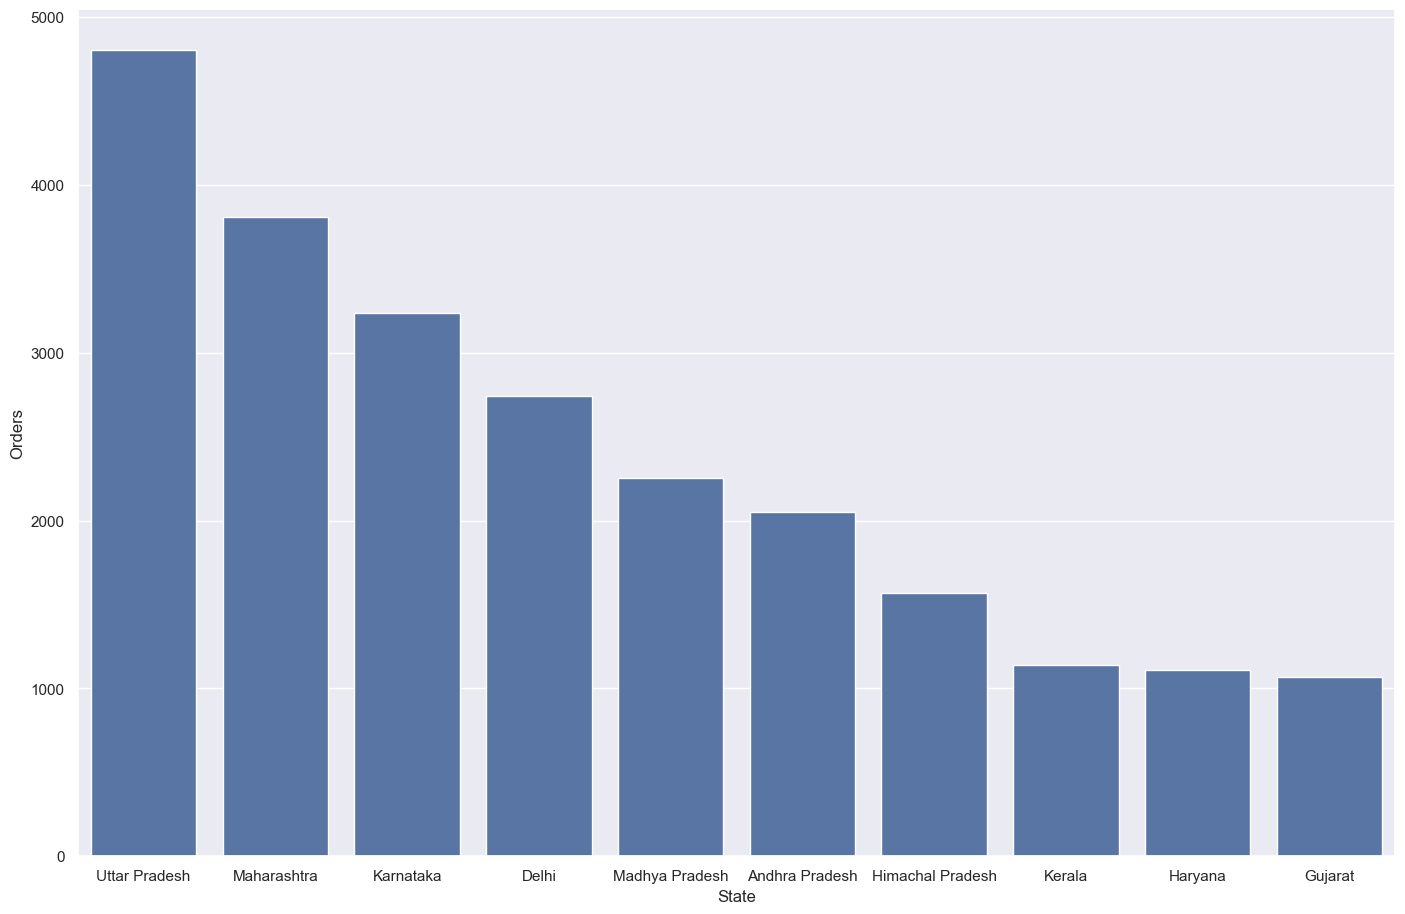

In [160]:
sns.set(rc={'figure.figsize':(17, 11)})
sns.barplot(data = sales_state_2, x = 'State', y='Orders')

##### it shows the state 'Uttar Pradesh' has both the highest Amount of purchase and highest number of orders.
##### Others are same in both graph of amount of purchase and orders except for 'kerala' comes before 'Haryana' in the Orders and States Graph while 'Kerala' is nowhere in the list of States in the Amount and States Graph

#### Marital Status

In [154]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

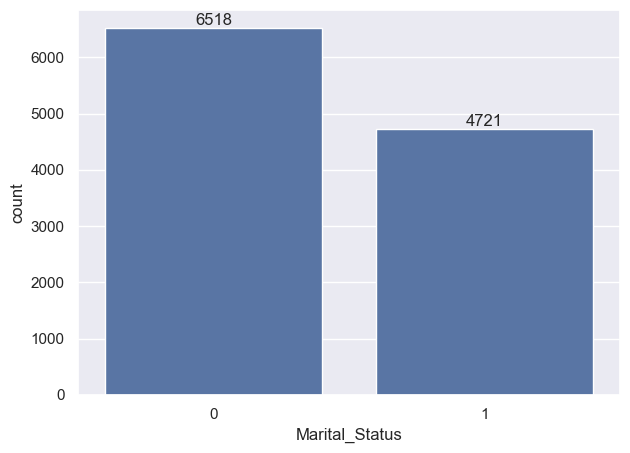

In [161]:
# looking at the count of the marital status (married(1) and single(0))
sns.set(rc={'figure.figsize': (7, 5)})
ax = sns.countplot(data=df, x = 'Marital_Status')
for bar in ax.containers:
    ax.bar_label(bar)

In [ ]:
# look at the marital status based on amount
sales_ms = df.groupby(['Marital_Status'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sales_ms

,Marital_Status,Amount
0,0,62125384
1,1,44123745


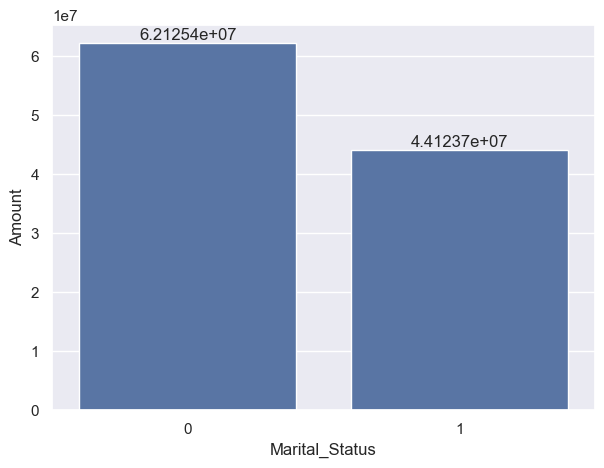

In [169]:
ax = sns.barplot(data = sales_ms, x = 'Marital_Status', y='Amount')
for bar in ax.containers:
    ax.bar_label(bar)

In [171]:
# looking at the gender of each buyer with marital status
sales_ms_g = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by="Amount")
sales_ms_g

,Marital_Status,Gender,Amount
3,1,M,13574538
1,0,M,18338738
2,1,F,30549207
0,0,F,43786646


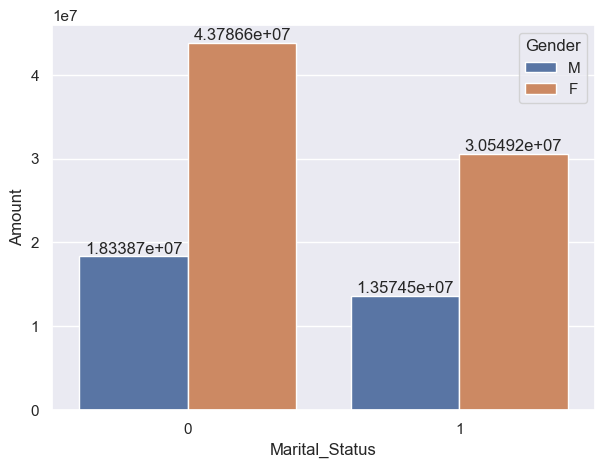

In [175]:
ax = sns.barplot(data = sales_ms_g, x = 'Marital_Status', y= 'Amount', hue='Gender')
# or we could check it has:
# ax = sns.barplot(data = sales_ms_g, x = 'Gender', y= 'Amount', hue='Marital_Status')
for bar in ax.containers:
    ax.bar_label(bar)

#### *From above graphs we can see that most of the buyers are single (women) and they have a high purchasing power(amount)



#### Occupation

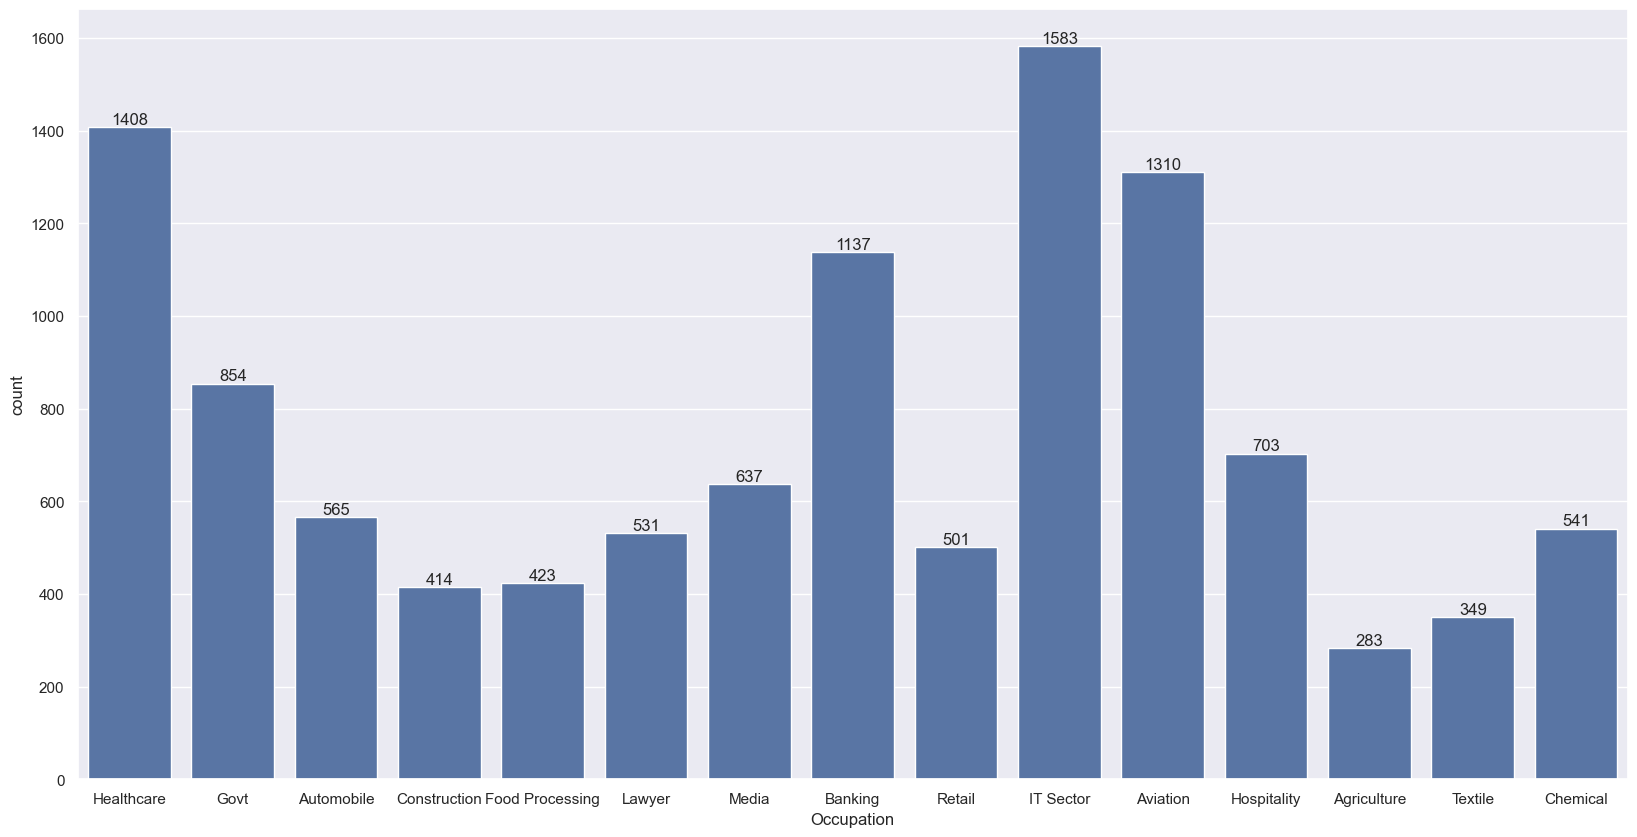

In [178]:
sns.set(rc={'figure.figsize':(20, 10)})
ax = sns.countplot(data = df, x='Occupation')
for bar in ax.containers:
    ax.bar_label(bar)

In [179]:
sales_occupation = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sales_occupation

,Occupation,Amount
10,IT Sector,14755079
8,Healthcare,13034586
2,Aviation,12602298
3,Banking,10770610
7,Govt,8517212
9,Hospitality,6376405
12,Media,6295832
1,Automobile,5368596
4,Chemical,5297436
11,Lawyer,4981665


<Axes: xlabel='Occupation', ylabel='Amount'>

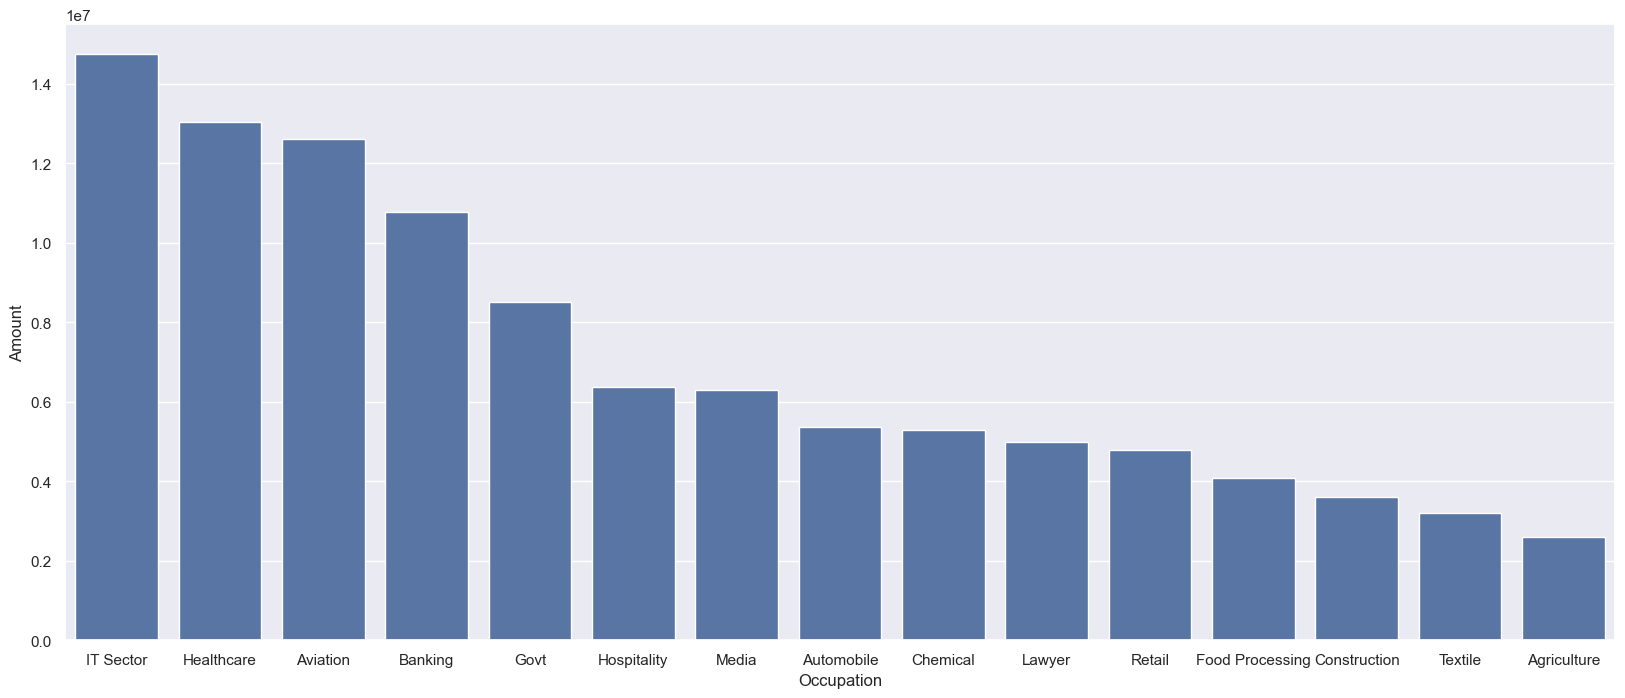

In [181]:
sns.set(rc={'figure.figsize': (20,8)})
sns.barplot(data = sales_occupation, x ='Occupation', y='Amount')


#### From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector

### Product Category

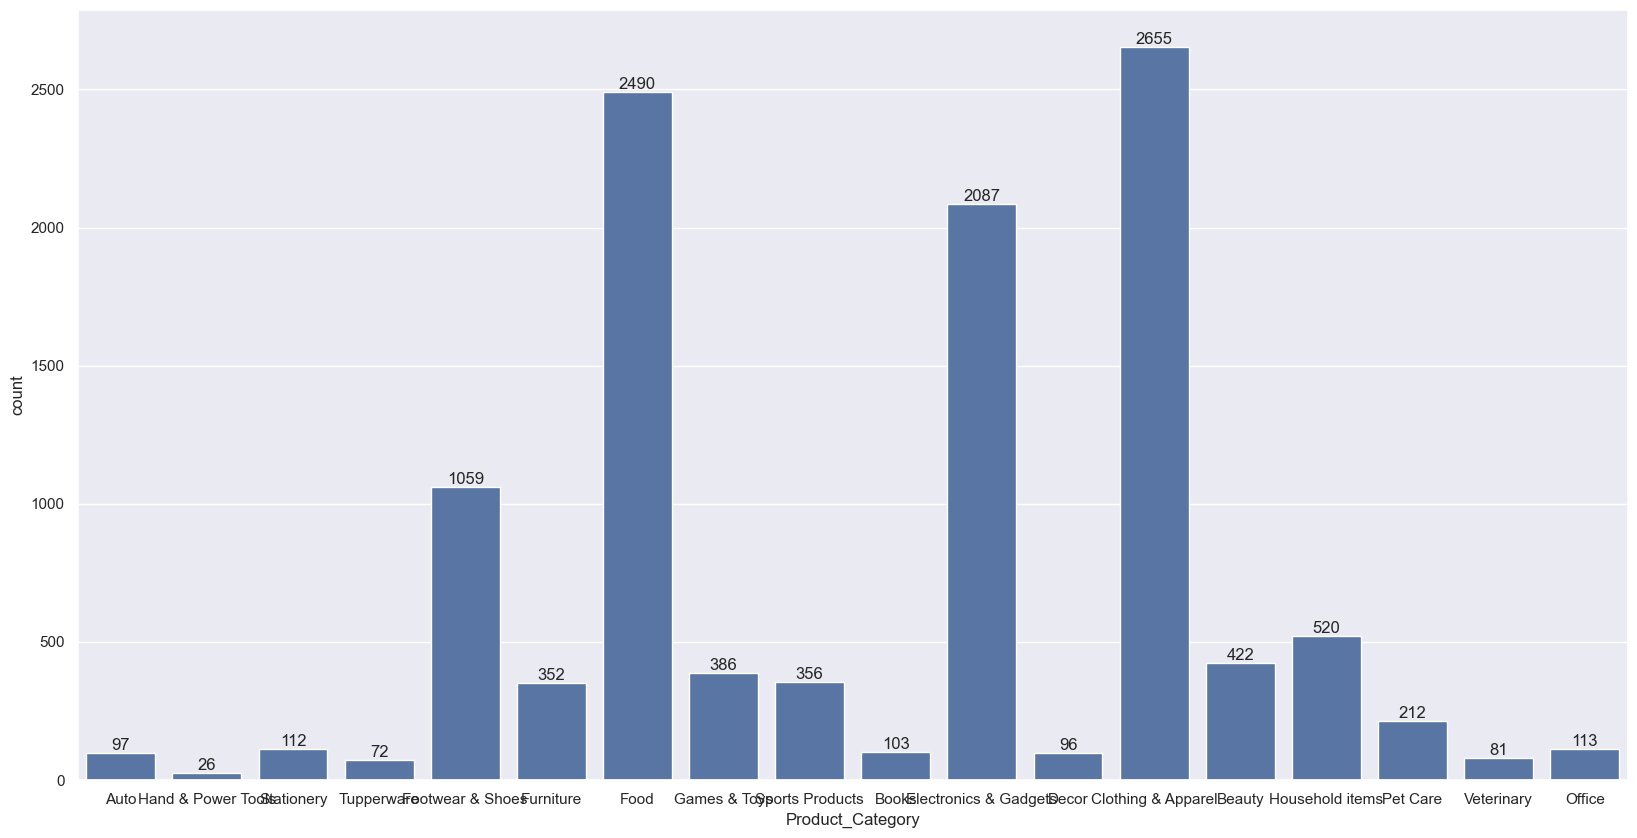

In [189]:
sns.set(rc={'figure.figsize':(20, 10)})
# fx = df.sort_values('Product_Category', ascending=False)
ax = sns.countplot(data = df, x='Product_Category')
for bar in ax.containers:
    ax.bar_label(bar)

In [184]:
sales_pc = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sales_pc

,Product_Category,Amount
6,Food,33933883
3,Clothing & Apparel,16495019
5,Electronics & Gadgets,15643846
7,Footwear & Shoes,15575209
8,Furniture,5440051
9,Games & Toys,4331694
14,Sports Products,3635933
1,Beauty,1959484
0,Auto,1958609
15,Stationery,1676051


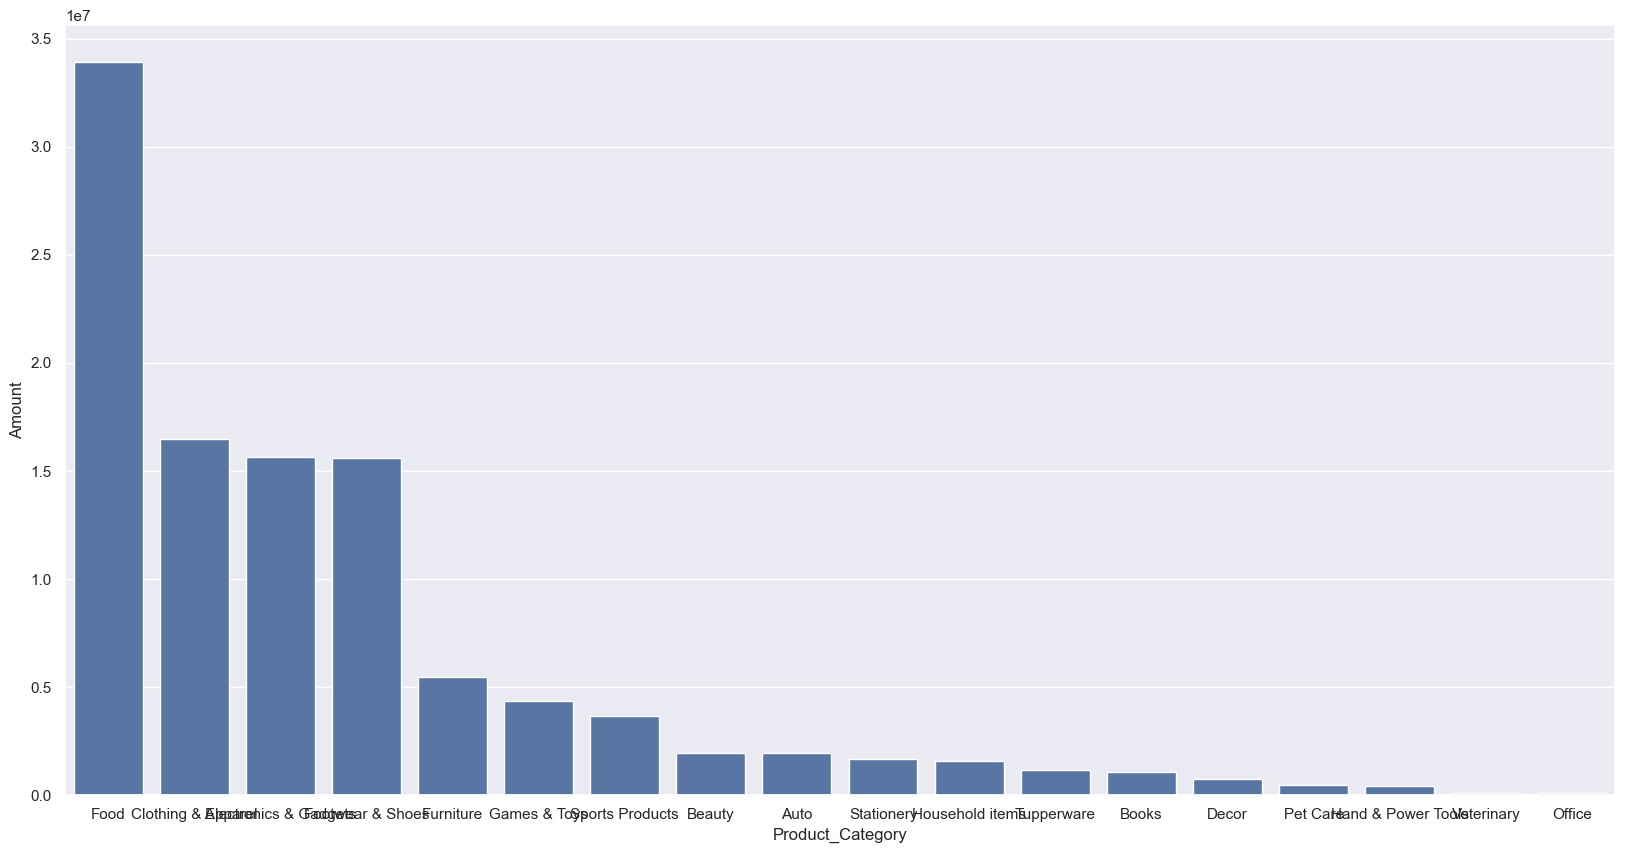

In [186]:
ax = sns.barplot(data = sales_pc, x = 'Product_Category', y='Amount')

#### From above graphs we can see that the 'Clothing' category has the highest number of orders/purchases while the 'Food' category has the highest total sum of goods bought/purchasing power

### Product Id

In [197]:
# to see which is the top selling product based on the product's id
sales_pid = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
sales_pid

,Product_ID,Orders
1679,P00265242,127
644,P00110942,116
1504,P00237542,91
1146,P00184942,82
171,P00025442,79
679,P00114942,79
888,P00145042,76
708,P00117942,76
298,P00044442,75
643,P00110842,74


In [194]:
df[df['Product_ID'] == 'P00265242'].count()

User_ID             53
Cust_name           53
Product_ID          53
Gender              53
Age Group           53
Age                 53
Marital_Status      53
State               53
Zone                53
Occupation          53
Product_Category    53
Orders              53
Amount              53
dtype: int64

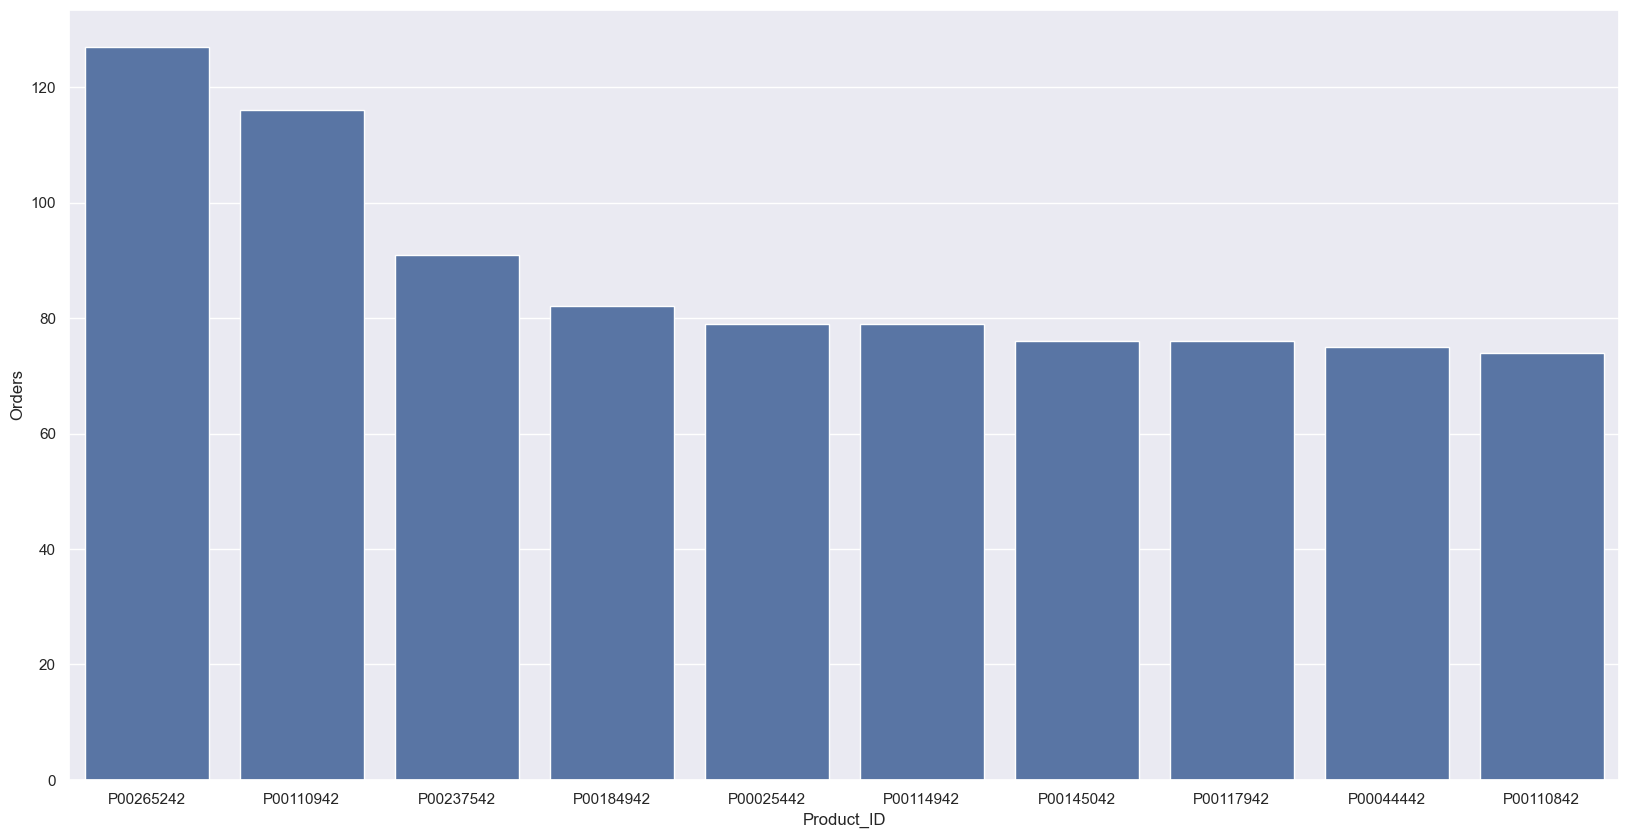

In [201]:
ax = sns.barplot(data = sales_pid, x = 'Product_ID', y='Orders')

In [204]:
# another way of doing what we've been doing
df.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values(ascending=False)

Product_ID
P00265242    127
P00110942    116
P00237542     91
P00184942     82
P00025442     79
P00114942     79
P00117942     76
P00145042     76
P00044442     75
P00110842     74
Name: Orders, dtype: int64

<Axes: xlabel='Product_ID'>

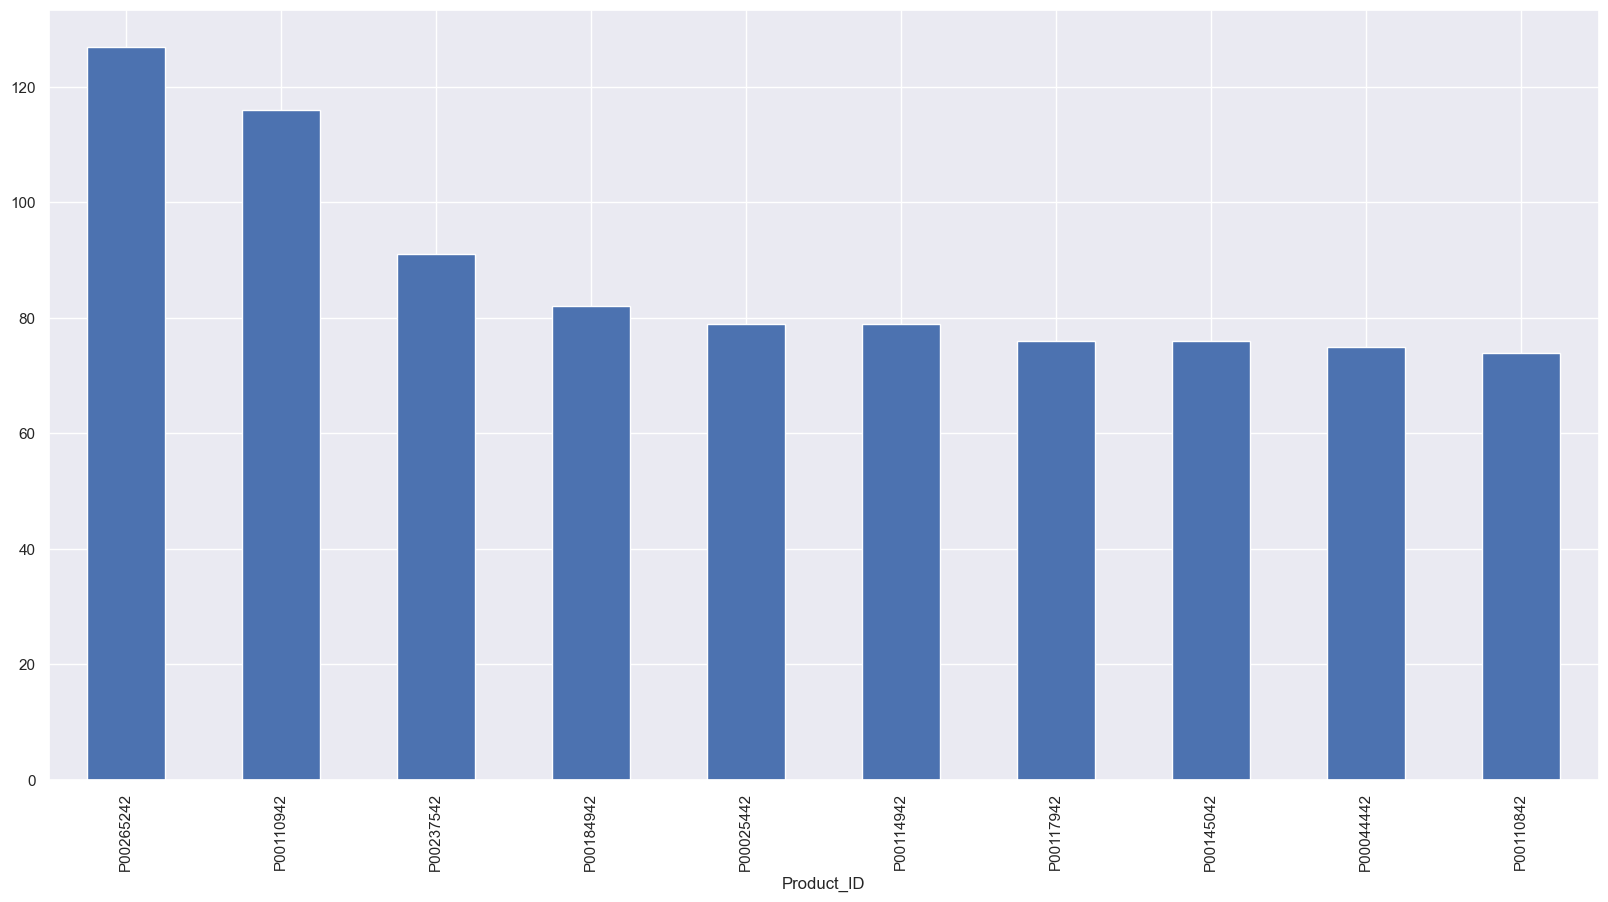

In [206]:
# then add .plot(kind='bar') to the line above to plot the bar graph
df.groupby(['Product_ID'])['Orders'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

#### So Conclusion

#### Single women from age group 26-35 yrs from UP, Maharastra and Kamataka working in IT,Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category.



## Project Activities

. Performed data cleaning and manipulation

. Performed exploratory data analysis (EDA) using pandas, matplotlib and seaborn libraries

.Improved customer experience by identifying potential customers across different states, occupation, gender and age groups

.Improved sales by identifying most selling product categories and products, which can help to plan inventory and hence meet the demands